<a href="https://colab.research.google.com/github/PavitranBhat/customer-churn-prediction-clv-analysis/blob/main/customer_churn_prediction_clv_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Step 2: Load your dataset
df = pd.read_csv("small_ecommerce_churn.csv")

In [16]:
# Step 3: Quick overview
print(df.head())          # Show first few rows
print(df.info())          # Data types and missing values
print(df.describe())      # Summary stat

  customer_id  age  gender      region  account_age_months  num_orders  \
0    CUST0001   56  Female       Texas                  21           8   
1    CUST0002   69  Female       Texas                  57          28   
2    CUST0003   46    Male  California                  36          28   
3    CUST0004   32    Male    Illinois                  10          37   
4    CUST0005   60  Female    New York                  37          41   

   avg_order_value  total_spent  days_since_last_order  satisfaction_score  \
0            20.64       165.12                    347                   7   
1            83.21      2329.88                     17                   8   
2           216.87      6072.36                    128                   3   
3           269.61      9975.57                    364                   6   
4           158.39      6493.99                    251                   2   

   num_support_tickets  churn  
0                    4      1  
1                    0

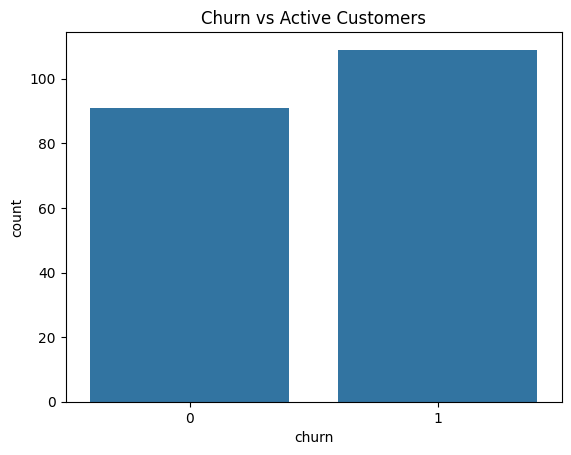

In [17]:
# Step 4: Check churn distribution
sns.countplot(x='churn', data=df)
plt.title("Churn vs Active Customers")
plt.show()

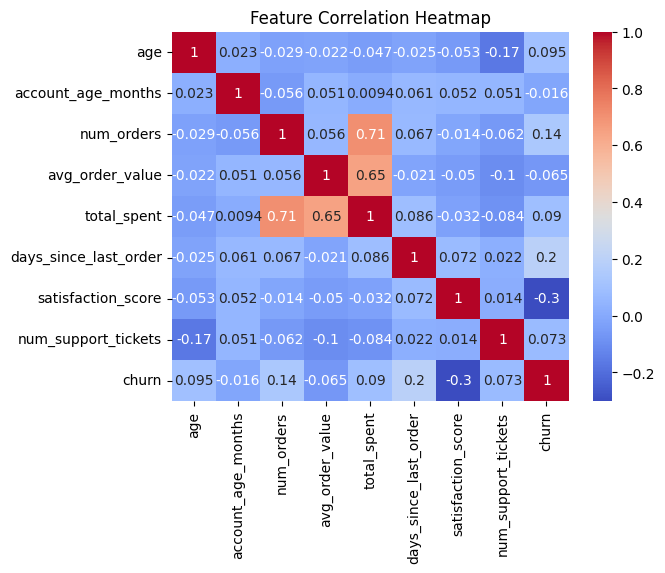

In [18]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

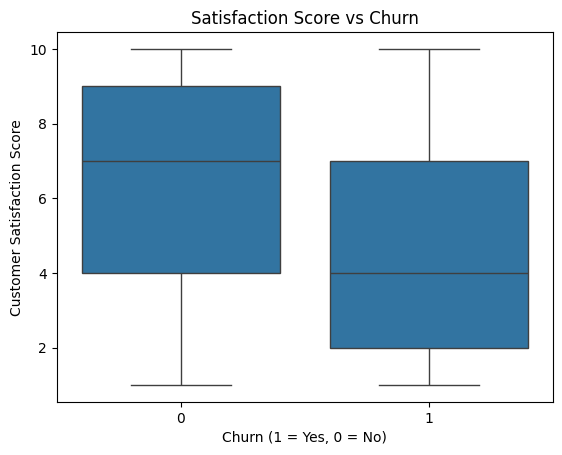

In [19]:
sns.boxplot(x='churn', y='satisfaction_score', data=df)
plt.title("Satisfaction Score vs Churn")
plt.xlabel("Churn (1 = Yes, 0 = No)")
plt.ylabel("Customer Satisfaction Score")
plt.show()

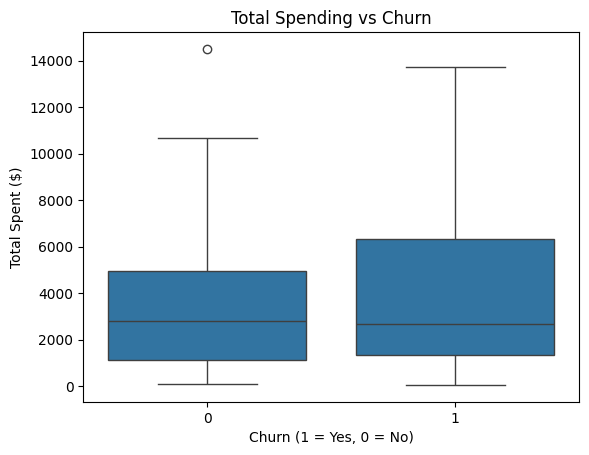

In [20]:
sns.boxplot(x='churn', y='total_spent', data=df)
plt.title("Total Spending vs Churn")
plt.xlabel("Churn (1 = Yes, 0 = No)")
plt.ylabel("Total Spent ($)")
plt.show()


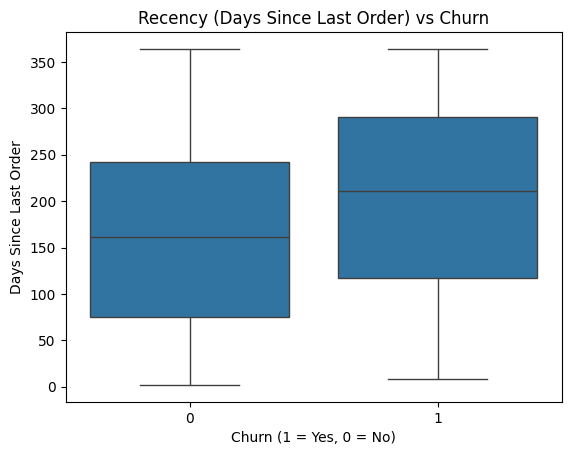

In [21]:
sns.boxplot(x='churn', y='days_since_last_order', data=df)
plt.title("Recency (Days Since Last Order) vs Churn")
plt.xlabel("Churn (1 = Yes, 0 = No)")
plt.ylabel("Days Since Last Order")
plt.show()


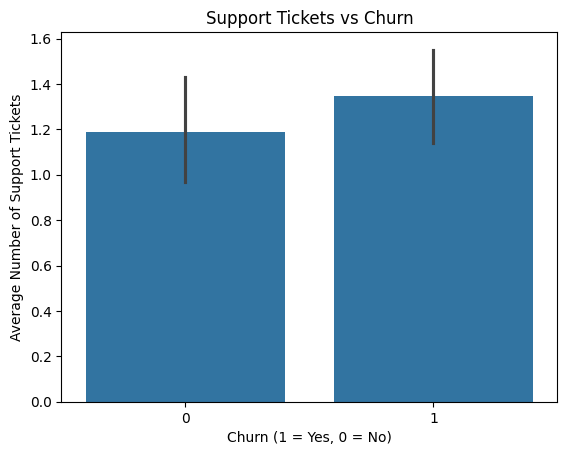

In [22]:
sns.barplot(x='churn', y='num_support_tickets', data=df)
plt.title("Support Tickets vs Churn")
plt.xlabel("Churn (1 = Yes, 0 = No)")
plt.ylabel("Average Number of Support Tickets")
plt.show()


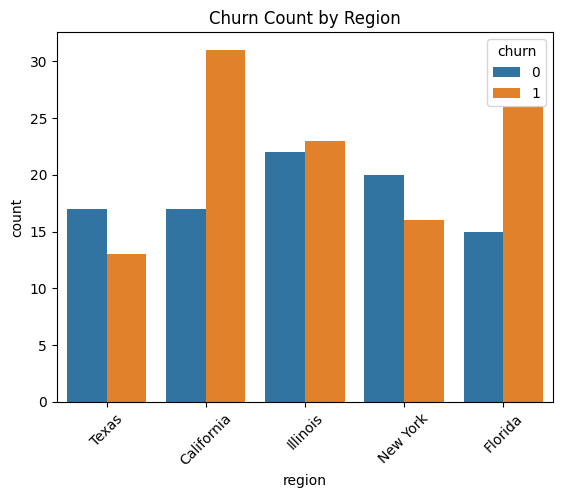

In [23]:
sns.countplot(x='region', hue='churn', data=df)
plt.title("Churn Count by Region")
plt.xticks(rotation=45)
plt.show()


Build Your Churn Prediction Model


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("small_ecommerce_churn.csv")

In [27]:
# 3️ Select features (X) and target (y)
X = df[['age', 'account_age_months', 'num_orders', 'avg_order_value',
        'days_since_last_order', 'satisfaction_score', 'num_support_tickets']]
y = df['churn']

In [28]:
 # Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
# 5️ Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
# 6️ Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [31]:
# 7️ Make predictions
y_pred = model.predict(X_test_scaled)

In [32]:
# 8️ Evaluate model performance
print("✅ Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n🔍 Classification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 0.7

📊 Confusion Matrix:
 [[11  4]
 [ 8 17]]

🔍 Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.73      0.65        15
           1       0.81      0.68      0.74        25

    accuracy                           0.70        40
   macro avg       0.69      0.71      0.69        40
weighted avg       0.72      0.70      0.70        40



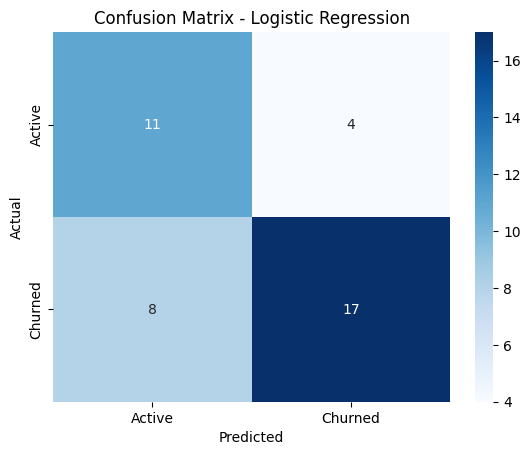

In [33]:
# 9️ Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [34]:
# 10 Check feature importance (coefficients)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n💡 Feature Importance (Logistic Regression Coefficients):")
display(importance)


💡 Feature Importance (Logistic Regression Coefficients):


,Feature,Coefficient
4,days_since_last_order,0.602398
0,age,0.241487
2,num_orders,0.148432
6,num_support_tickets,0.122405
1,account_age_months,-0.028425
3,avg_order_value,-0.195991
5,satisfaction_score,-0.675989


Interpreting Results & Identifying At-Risk Customers


/tmp/ipython-input-3673420849.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance, palette='coolwarm')


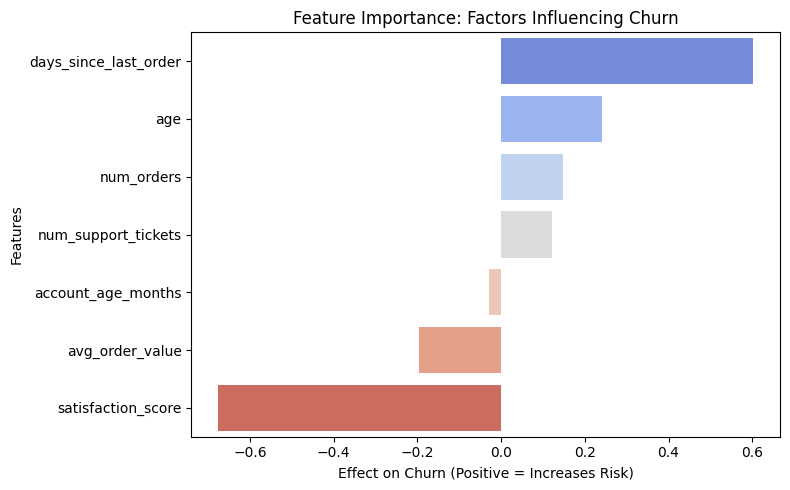

In [35]:
# ==============================================
# 🎯 Step 5.1: Visualize Feature Importance
# ==============================================
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=importance, palette='coolwarm')
plt.title("Feature Importance: Factors Influencing Churn")
plt.xlabel("Effect on Churn (Positive = Increases Risk)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [36]:
# ==============================================
# 📈 Step 5.2: Get churn probabilities
# ==============================================
df['churn_probability'] = model.predict_proba(scaler.transform(X))[:, 1]

# Preview top customers most likely to churn
high_risk = df.sort_values(by='churn_probability', ascending=False).head(10)
high_risk[['customer_id', 'region', 'satisfaction_score', 'days_since_last_order', 'churn_probability']]




,customer_id,region,satisfaction_score,days_since_last_order,churn_probability
22,CUST0023,Illinois,2,361,0.927820
67,CUST0068,California,1,349,0.918114
187,CUST0188,California,3,363,0.886985
179,CUST0180,Texas,1,309,0.886546
159,CUST0160,Texas,3,356,0.876735
11,CUST0012,Florida,1,344,0.876181
90,CUST0091,Florida,3,302,0.870997
4,CUST0005,New York,2,251,0.857883
37,CUST0038,California,5,318,0.851002
111,CUST0112,California,2,234,0.845821


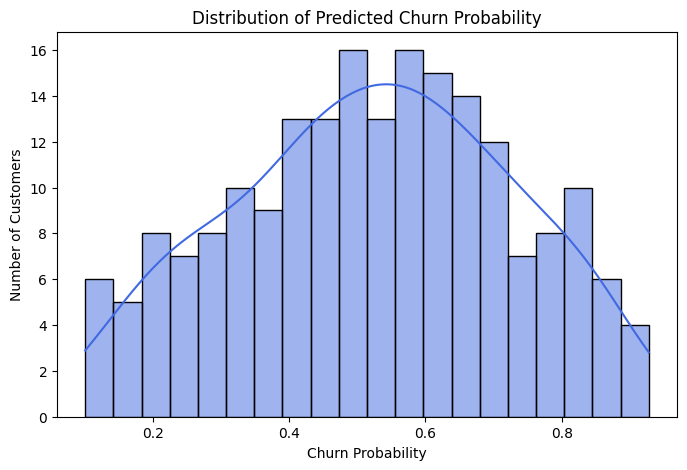

In [37]:
# ==============================================
# 📊 Step 5.3: Distribution of churn probabilities
# ==============================================
plt.figure(figsize=(8,5))
sns.histplot(df['churn_probability'], bins=20, kde=True, color='royalblue')
plt.title("Distribution of Predicted Churn Probability")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")
plt.show()


In [38]:
# ==============================================
# ⚠️ Step 5.4: Categorize churn risk levels
# ==============================================
def categorize_risk(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['churn_risk_segment'] = df['churn_probability'].apply(categorize_risk)

# Count customers per segment
risk_summary = df['churn_risk_segment'].value_counts()
print("🧩 Churn Risk Breakdown:\n", risk_summary)


🧩 Churn Risk Breakdown:
 churn_risk_segment
Medium Risk    101
Low Risk        56
High Risk       43
Name: count, dtype: int64


/tmp/ipython-input-1278768901.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn_risk_segment', data=df, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='RdYlBu')


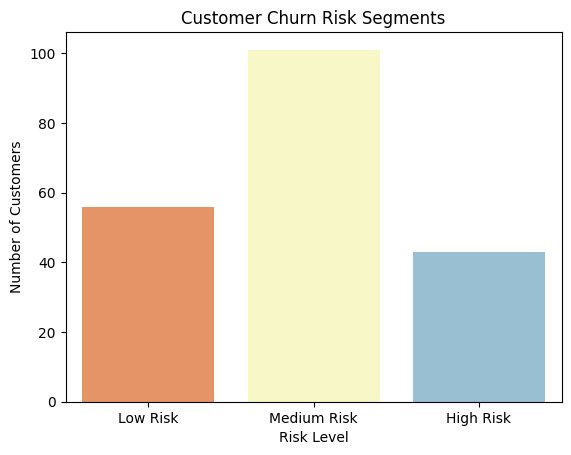

In [39]:
sns.countplot(x='churn_risk_segment', data=df, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='RdYlBu')
plt.title("Customer Churn Risk Segments")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.show()


In [41]:
# ==============================================
# 💰 Step 6: Customer Lifetime Value (CLV)
# ==============================================

# Estimate purchase frequency = total orders / account age (in months)
df['purchase_frequency'] = df['num_orders'] / df['account_age_months']

# Estimate expected customer lifespan (in months)
# Customers with higher churn risk have shorter expected lifespans
df['expected_lifespan_months'] = (1 - df['churn_probability']) * 24  # up to 2 years max

# Calculate CLV
df['CLV'] = df['avg_order_value'] * df['purchase_frequency'] * df['expected_lifespan_months']

# Show top 10 customers by CLV
top_clv = df.sort_values(by='CLV', ascending=False).head(10)
top_clv[['customer_id', 'region', 'avg_order_value', 'purchase_frequency', 'expected_lifespan_months', 'CLV']]


,customer_id,region,avg_order_value,purchase_frequency,expected_lifespan_months,CLV
109,CUST0110,California,246.81,34.000000,7.786149,65337.776950
176,CUST0177,Florida,133.00,22.000000,11.693262,34214.485763
180,CUST0181,California,140.74,16.000000,14.203125,31983.165191
140,CUST0141,Illinois,109.20,16.000000,12.076765,21100.524539
55,CUST0056,Illinois,203.91,7.600000,12.805888,19845.488911
45,CUST0046,New York,162.11,5.000000,21.499163,17426.146469
151,CUST0152,Florida,195.93,5.333333,14.763194,15426.947614
91,CUST0092,Illinois,221.95,6.857143,7.078589,10773.208260
5,CUST0006,Florida,164.31,4.000000,15.234655,10012.824687
89,CUST0090,Texas,289.86,1.764706,18.667547,9548.779767


In [43]:
# ==============================================
#  Step 7: Combine CLV + Churn Risk into Segments
# ==============================================

# Define thresholds for segmentation
clv_threshold = df['CLV'].median()
churn_threshold = 0.5  # 50% churn risk

# Create segments
def segment_customer(row):
    if row['CLV'] >= clv_threshold and row['churn_probability'] >= churn_threshold:
        return 'High Value & At Risk'
    elif row['CLV'] >= clv_threshold and row['churn_probability'] < churn_threshold:
        return ' High Value & Loyal'
    elif row['CLV'] < clv_threshold and row['churn_probability'] >= churn_threshold:
        return 'Low Value & At Risk'
    else:
        return ' Low Value & Loyal'

df['Customer_Segment'] = df.apply(segment_customer, axis=1)

# View sample
df[['customer_id', 'CLV', 'churn_probability', 'Customer_Segment']].head(10)


,customer_id,CLV,churn_probability,Customer_Segment
0,CUST0001,37.957841,0.798855,Low Value & At Risk
1,CUST0002,714.037683,0.272134,Low Value & Loyal
2,CUST0003,1768.898826,0.563045,High Value & At Risk
3,CUST0004,8365.003204,0.650605,High Value & At Risk
4,CUST0005,598.643992,0.857883,Low Value & At Risk
5,CUST0006,10012.824687,0.365223,High Value & Loyal
6,CUST0007,630.361568,0.431677,Low Value & Loyal
7,CUST0008,794.154262,0.512515,Low Value & At Risk
8,CUST0009,553.724343,0.236207,Low Value & Loyal
9,CUST0010,692.091253,0.619213,Low Value & At Risk


/tmp/ipython-input-251763208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Customer_Segment', data=df, order=df['Customer_Segment'].value_counts().index, palette='Set2')


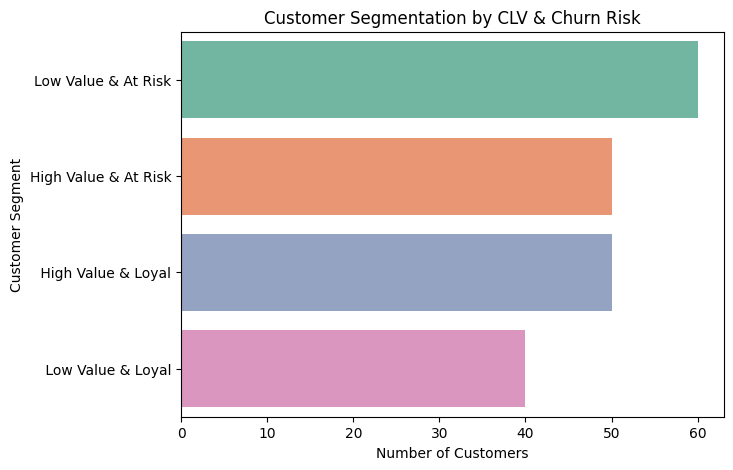

In [44]:
# Count customers in each segment
plt.figure(figsize=(7,5))
sns.countplot(y='Customer_Segment', data=df, order=df['Customer_Segment'].value_counts().index, palette='Set2')
plt.title("Customer Segmentation by CLV & Churn Risk")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.show()


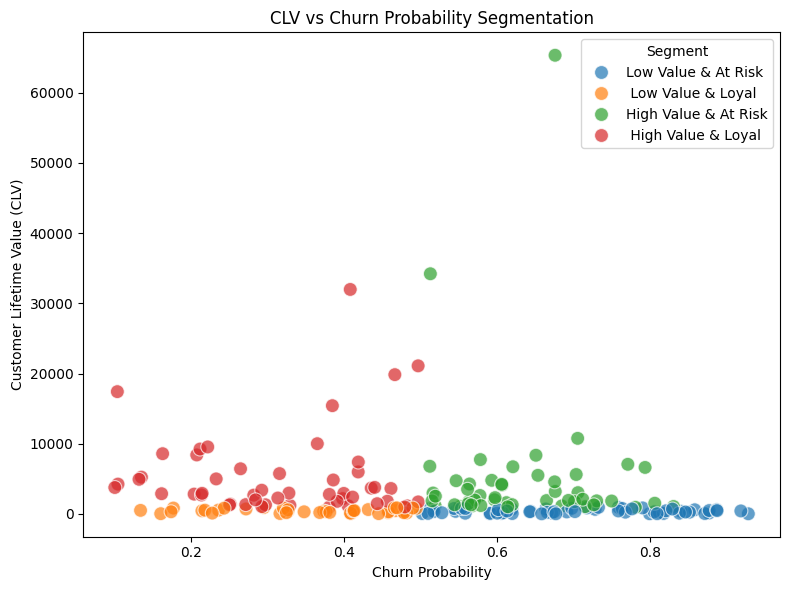

In [45]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='churn_probability', y='CLV', hue='Customer_Segment', data=df, s=100, alpha=0.7)
plt.title("CLV vs Churn Probability Segmentation")
plt.xlabel("Churn Probability")
plt.ylabel("Customer Lifetime Value (CLV)")
plt.legend(title='Segment')
plt.tight_layout()
plt.show()


In [46]:
df.to_csv("final_churn_clv_segments.csv", index=False)
